## 📊 Bank Marketing Prediction using Machine Learning

# 🎯 Objective

The goal of this project is to identify customers who are likely to subscribe to a term deposit and help the bank improve its marketing strategy.

# 🧠 Business Problem

Banks invest heavily in direct marketing campaigns (calls, emails, etc.), but not all customers respond positively.
Predicting customer response helps:

- Improve campaign success rate
- Target high-potential customers
- Reduce unnecessary marketing costs
- Increase conversion rate of term deposits
- Optimize resource allocation for marketing teams

## 📌 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

import joblib
import warnings
warnings.filterwarnings("ignore")

## 📌 2. Load Dataset

In [2]:
df = pd.read_csv("bank-full.csv", sep=';')
df

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no


In [5]:
# Check target type first
print(df['y'].unique())

['no' 'yes']


## 📌 3. Fix Target Column

In [6]:
df['y'] = df['y'].astype(str).str.strip().str.lower()
df['y'] = df['y'].map({'yes':1, 'no':0})

In [7]:
print(df['y'].unique())

[0 1]


## 📌 4. Basic Info

In [3]:
print(df.shape)

(45211, 17)


In [4]:
print(df.columns)

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')


In [5]:
print(df['y'].value_counts())

y
no     39922
yes     5289
Name: count, dtype: int64


In [6]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

## 📊 5. Exploratory Data Analysis

### Target Distribution

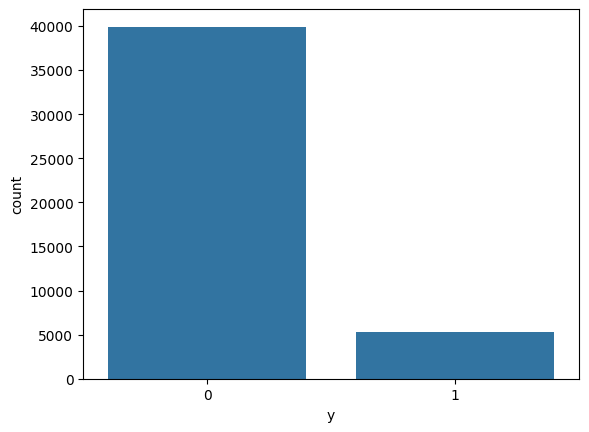

In [9]:
sns.countplot(x='y', data=df)
plt.show()

- Dataset is imbalanced with more 'no' than 'yes'.

### Bivariate Analysis

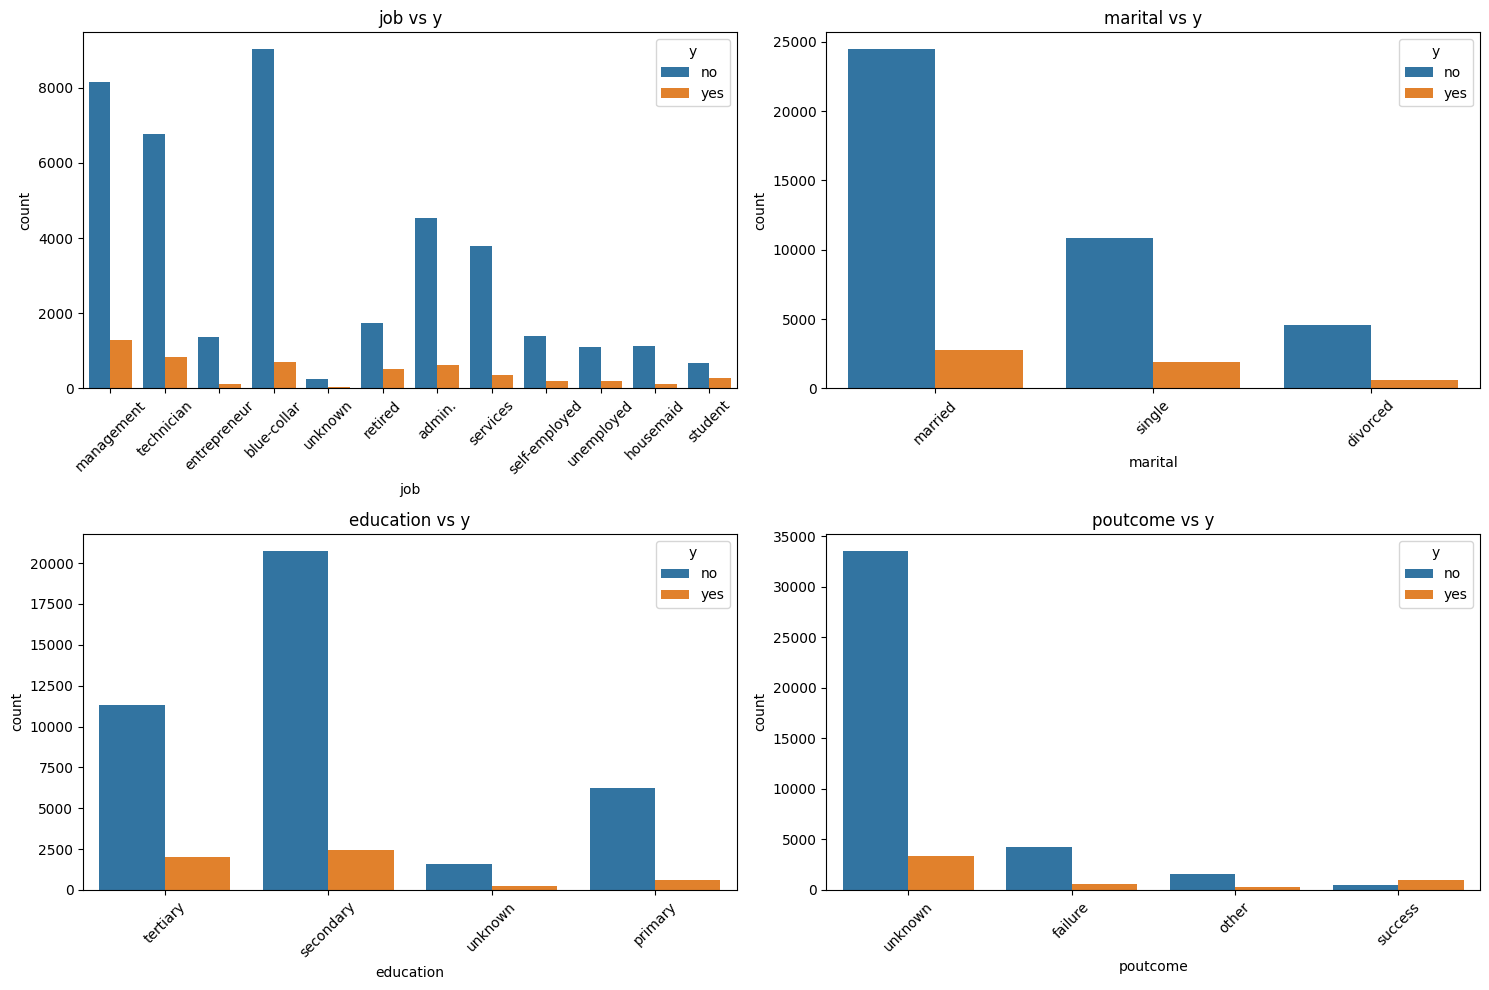

In [9]:
cols = ['job', 'marital', 'education', 'poutcome']

plt.figure(figsize=(15,10))

for i, col in enumerate(cols, 1):
    plt.subplot(2, 2, i)
    sns.countplot(x=col, hue='y', data=df)
    plt.title(f"{col} vs y")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 📊 Insights (Categorical Features vs Target)

### 🧑‍💼 Job vs Target (y)
- Customers in **management, technician, and blue-collar jobs** have the highest number of contacts but relatively lower subscription rates.
- **Students and retired individuals** show comparatively higher conversion rates despite lower counts.
- Indicates that **younger and retired segments may be more responsive** to term deposit offers.

---

### 💍 Marital Status vs Target (y)
- **Married customers** dominate the dataset but have a lower conversion rate.
- **Single customers** show a slightly better subscription proportion.
- Suggests that **single individuals may be more open to financial investments**.

---

### 🎓 Education vs Target (y)
- Customers with **secondary education** form the largest group but have moderate conversions.
- **Tertiary education** customers show relatively better subscription behavior.
- Indicates that **higher education level may positively influence financial decisions**.

---

### 📞 Previous Campaign Outcome (poutcome vs y)
- Customers with **previous success** have a significantly higher likelihood of subscribing again.
- **Failure and unknown outcomes** show very low conversion rates.
- This is one of the **most important predictive features**.

---

### 🧠 Overall Insights
- Certain customer segments (students, retired, educated individuals) are **more likely to subscribe**.
- Previous campaign success is a **strong indicator of future success**.
- Marketing efforts should focus more on **high-response groups rather than mass targeting**.

### Numerical vs Target

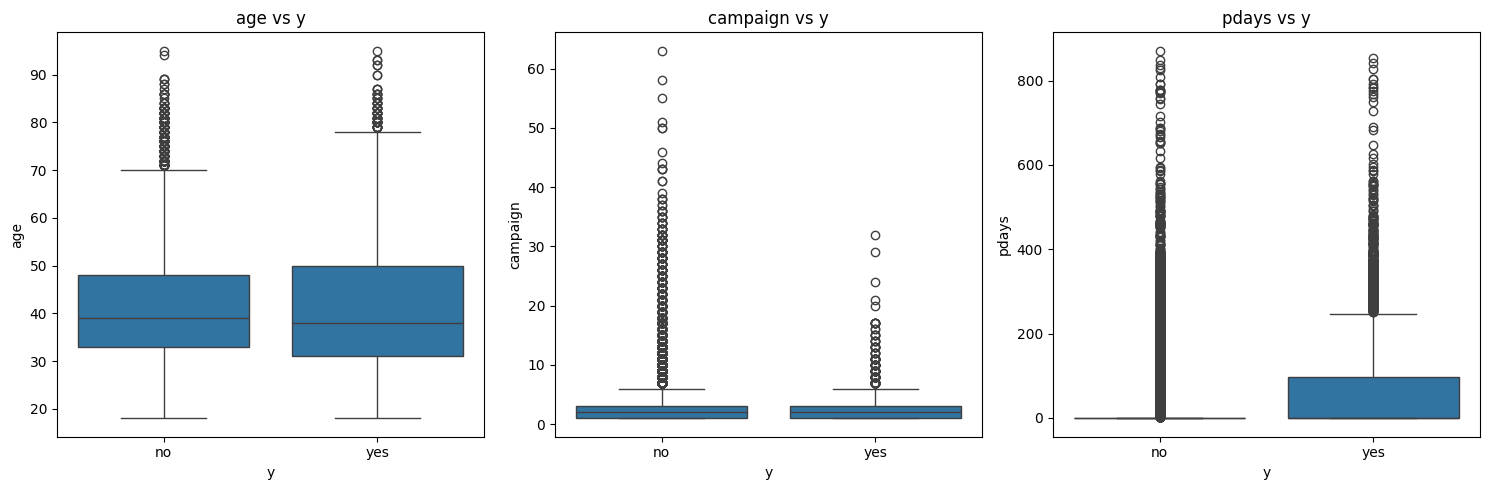

In [10]:
cols = ['age', 'campaign', 'pdays']

fig, axes = plt.subplots(1, 3, figsize=(15,5))

for i, col in enumerate(cols):
    sns.boxplot(x='y', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'{col} vs y')

plt.tight_layout()
plt.show()

- Age distribution is similar for both classes, but customers who subscribed (`yes`) tend to be slightly older.
- Campaign contacts are generally low, but higher number of contacts is associated with lower subscription chances.
- Customers contacted fewer times are more likely to subscribe, indicating over-contacting reduces effectiveness.
- For `pdays`, most customers were not previously contacted (value near 0 or 999), especially in the "no" class.
- Customers who were contacted recently in previous campaigns show slightly better subscription rates.
- Overall, fewer contacts and recent interactions increase the likelihood of subscription.  

### Numerical Distribution
- Most customers are in middle age group.

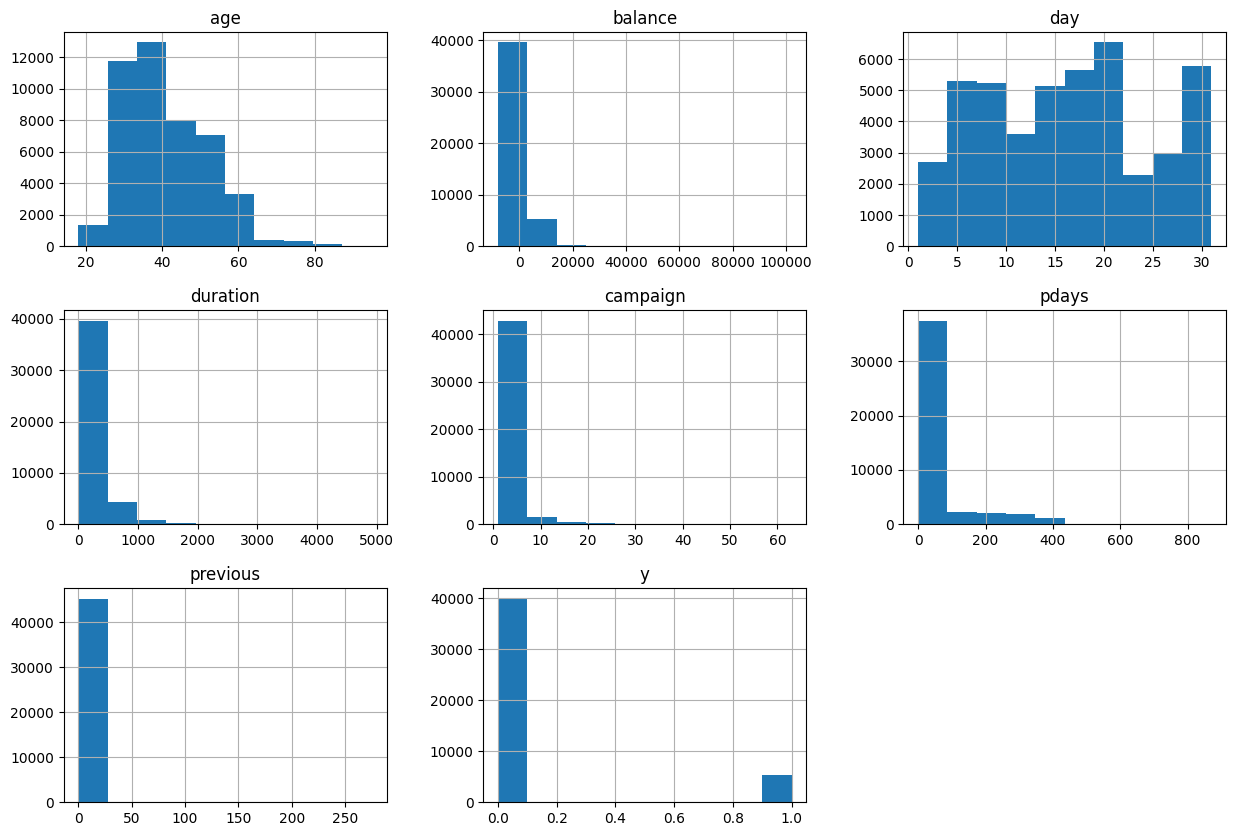

In [10]:
df.hist(figsize=(15,10))
plt.show()

- Age is slightly right-skewed, with most customers between 30–50 years.  
- Balance is highly right-skewed, with most customers having low balance and few extreme outliers.  
- Duration is heavily right-skewed, indicating most calls are short, with few very long calls.  
- Campaign and previous contacts are also right-skewed, showing most customers are contacted only a few times.  
- Pdays has a strong skew with many values near 0 or high (indicating no previous contact).  
- Target variable (y) is highly imbalanced, with far more “no” than “yes” responses.  

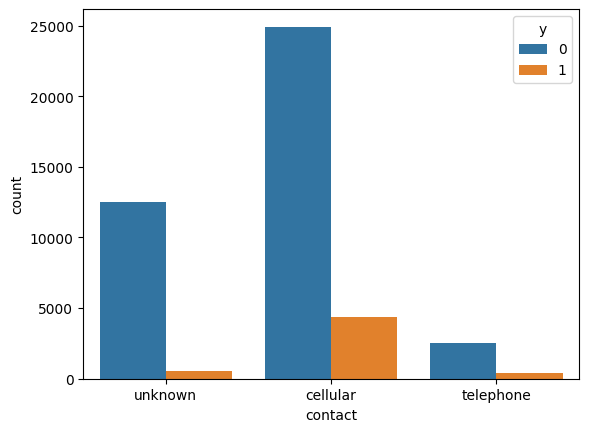

In [12]:
sns.countplot(x='contact', hue='y', data=df)
plt.show()

### Outlier Detection
- Some outliers present but not extreme.

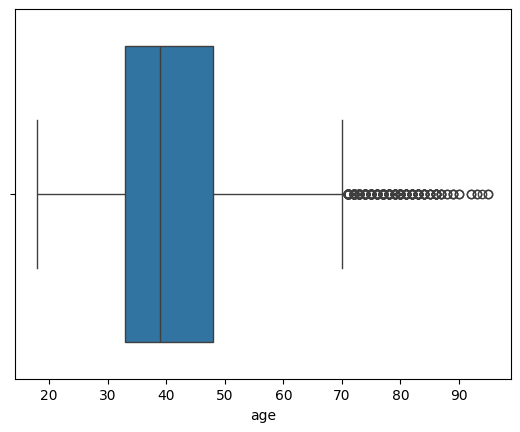

In [13]:
sns.boxplot(x=df['age'])
plt.show()

## 🧠 EDA Summary

- Dataset is highly imbalanced with majority "no" responses.
- Most customers are middle-aged with low balance.
- Previous campaign outcome strongly influences subscription.
- Fewer contacts and recent interactions improve success rate.
- Certain groups (students, retired, educated) are more responsive.

## ⚠️ 6. Label Encoding (for Correlation)

In [23]:
df_encoded = df.copy()
le = LabelEncoder()
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

### Correlation Matrix

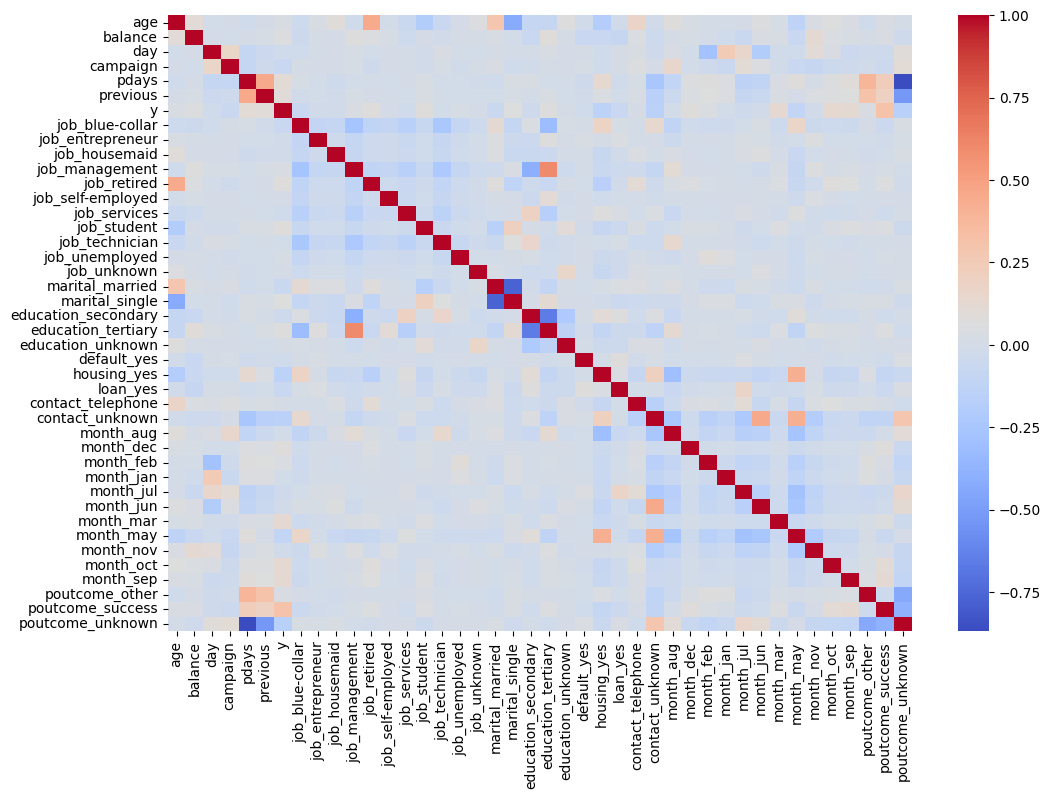

In [24]:
plt.figure(figsize=(12,8))
sns.heatmap(df_encoded.corr(), cmap='coolwarm')
plt.show()

# 💡 Insight:

- Most features show low correlation, indicating minimal multicollinearity and a stable dataset for modeling.

- No highly correlated feature pairs (>0.8), so feature removal is not strictly required.

- Variables like pdays, previous, and poutcome show relatively stronger relationships and are important for prediction.

- Many features have near-zero correlation, suggesting non-linear relationships may exist.

- One-hot encoded categorical variables individually show low correlation but are collectively useful.

- Overall, tree-based models (Random Forest, XGBoost) may perform better than linear models due to weak linear relationships.

## 📌 7. Data Preprocessing

Dropping duration to prevent data leakage.

In [15]:
# Fix pdays (-1 issue)
df['pdays'] = df['pdays'].replace(-1, 0)

# Drop leakage column
df = df.drop(columns=['duration'])

# One-hot encoding
df = pd.get_dummies(df, drop_first=True)

# Convert bool → int
df = df.astype(int)

In [16]:
X = df.drop('y', axis=1)
y = df['y']

## 📌 8. Train-Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)


#saves train and test data seprately as .csv files  to ensures reproducibility and prevents data leakage
train_df = X_train.copy()
train_df['y'] = y_train

test_df = X_test.copy()
test_df['y'] = y_test

train_df.to_csv("train_data.csv", index=False)
test_df.to_csv("test_data.csv", index=False)

## 📌 10. Handle Imbalance

In [18]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

## 📌 11. Model Training

In [25]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_sm)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train_sm)
y_pred_lr = lr.predict(X_test_scaled)

In [26]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_sm, y_train_sm)
y_pred_rf = rf.predict(X_test)

In [21]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
xgb.fit(X_train_sm, y_train_sm)
y_pred_xgb = xgb.predict(X_test)

## 📊 12. Model Evaluation
- Recall is important to identify maximum potential customers.
- Precision avoids unnecessary calls.
- F1-score balances both.

In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

def evaluate(y_test, y_pred):
    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_pred)
    }

results = pd.DataFrame({
    "LR": evaluate(y_test, y_pred_lr),
    "RF": evaluate(y_test, y_pred_rf),
    "XGB": evaluate(y_test, y_pred_xgb)
}).T

print(results)


     Accuracy  Precision    Recall        F1   ROC-AUC
LR   0.857569   0.360775  0.281664  0.316348  0.607770
RF   0.880128   0.481638  0.322306  0.386183  0.638173
XGB  0.873493   0.450688  0.371456  0.407254  0.655734


## 🤖 Model Comparison Report  

### 📊 Model Performance Summary  

#### Logistic Regression (LR)  
- Accuracy: 85.75%  
- Precision: 36.08%  
- Recall: 28.16%  
- F1-Score: 31.63%  
- ROC-AUC: 0.6077  
- Observation: Lowest performance; struggles to identify positive cases.  

#### Random Forest (RF)  
- Accuracy: 88.01% *(Highest)*  
- Precision: 48.16%  
- Recall: 32.23%  
- F1-Score: 38.62%  
- ROC-AUC: 0.6381  
- Observation: Better precision and accuracy, but recall is still moderate.  

#### XGBoost (XGB)  
- Accuracy: 87.34%  
- Precision: 45.06%  
- Recall: 37.14% *(Highest)*  
- F1-Score: 40.72% *(Highest)*  
- ROC-AUC: 0.6557 *(Highest)*  
- Observation: Best balance between precision and recall.  

---

### 📌 Key Insights  

- The dataset is **imbalanced**, leading to high accuracy but lower recall.  
- Recall is more important for this problem since missing potential customers impacts revenue.  
- XGBoost performs best in identifying actual subscribers.  

---

### 🏆 Best Model for Production  

**XGBoost is the preferred model because:**  
- Highest recall → captures more potential customers  
- Best F1-score → balanced performance  
- Highest ROC-AUC → strong classification ability  

---

### ⚠️ Limitations  

- All models have relatively low recall.  
- Class imbalance affects prediction performance.  

---

### 🔧 Recommendations for Improvement  

- Apply class balancing techniques (SMOTE, class weights)  
- Perform hyperparameter tuning  
- Adjust decision threshold instead of using default (0.5)  

---

### 🧠 Conclusion  

Although Random Forest has the highest accuracy, **XGBoost is the best model for deployment** as it better identifies customers likely to subscribe, aligning with business goals.

## 📊 Confusion Matrix

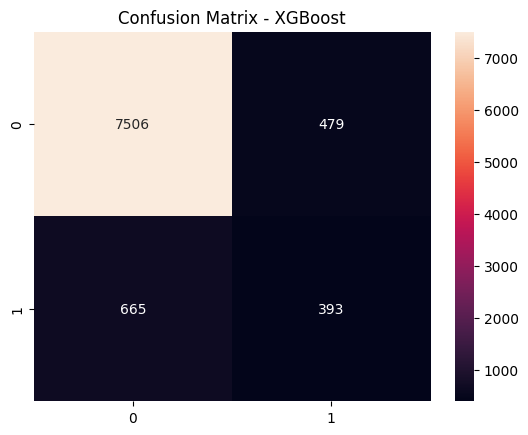

In [28]:
sns.heatmap(confusion_matrix(y_test, y_pred_xgb), annot=True, fmt='d')
plt.title("Confusion Matrix - XGBoost")
plt.show()

## ⚙️ 13. Hyperparameter Tuning

In [38]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train_sm, y_train_sm)

print("Best Params:", grid.best_params_)

Best Params: {'max_depth': 10, 'n_estimators': 200}


## 🔁 14. Cross Validation

In [39]:
from sklearn.model_selection import StratifiedKFold
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        random_state=42,
        eval_metric='logloss'
    ))
])

scores = cross_val_score(pipeline, X, y, cv=cv, scoring='f1')

pipeline.fit(X, y)

print("Cross-validation F1 Score:", scores)
print("Mean F1:", scores.mean())


Cross-validation F1 Score: [0.39503619 0.42099846 0.39717742 0.3973029  0.42181818]
Mean F1: 0.40646663122978743


In [40]:
import joblib

# IMPORTANT: save trained pipeline
joblib.dump(pipeline, "model.pkl")

['model.pkl']

In [37]:
print(pipeline)          

Pipeline(steps=[('smote', SMOTE(random_state=42)),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric='logloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.1,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                     

In [41]:
print(pipeline.predict(X[:5]))

[0 0 0 0 0]


# 💡 Suggestions for Bank Marketing Team  

- Focus on customers with **previous successful campaign outcomes**, as they are most likely to subscribe again.  
- Prioritize **students, retired, and higher-educated customers**, as they show better conversion rates.  
- Use **cellular communication** more than telephone, as it yields higher response rates.  
- Avoid excessive follow-ups; **limit the number of contacts**, as too many calls reduce customer interest.  
- Target customers who were **recently contacted (low pdays)**, as they are more responsive.  
- Design **personalized marketing campaigns** instead of mass targeting to improve conversion rates.  
- Offer **special incentives or tailored plans** to high-potential customers to increase subscriptions.  

# ⚠️ Challenges Faced During the Project  

## 📊 1. Imbalanced Dataset  
- The target variable (`y`) is highly imbalanced (more "no" than "yes").  
- This caused models to achieve high accuracy but low recall.  
- **Solution:** Focused on metrics like Recall, F1-score, and ROC-AUC instead of accuracy.

---

## 🧹 2. Data Preprocessing Complexity  
- Dataset contained multiple categorical variables with many categories (job, education, month, etc.).  
- Required proper encoding to make it suitable for machine learning models.  
- **Solution:** Applied One-Hot Encoding to convert categorical features into numerical format.

---

## ⚠️ 3. Irrelevant Feature (`duration`)  
- The `duration` feature strongly affects the target but is not available before the call.  
- Including it would lead to unrealistic model performance.  
- **Solution:** Removed `duration` to build a practical and deployable model.

---

## 🔗 4. Low Feature Correlation  
- Most features showed weak linear relationships with the target variable.  
- Linear models struggled to capture patterns.  
- **Solution:** Used advanced models like Random Forest and XGBoost to capture non-linear relationships.

---

## ⚙️ 5. Model Performance Trade-offs  
- Some models had high accuracy but low recall (missed potential customers).  
- Others improved recall but reduced precision.  
- **Solution:** Selected model based on business goal (maximize recall and conversions).

---

## 🧠 6. Feature Selection Difficulty  
- Large number of encoded features made it hard to identify the most important ones.  
- **Solution:** Used model-based importance (e.g., Random Forest, XGBoost feature importance).

---

## 📉 7. Overfitting Risk  
- Complex models like Random Forest and XGBoost may overfit the data.  
- **Solution:** Used train-test split and performance comparison to ensure generalization.

---

## ✅ Conclusion  
Despite challenges like class imbalance, feature complexity, and low correlation, appropriate preprocessing, model selection, and evaluation strategies helped in building an effective predictive model.